<a href="https://colab.research.google.com/github/Anoushehm/intro-ml-course-winter2026/blob/main/Activity_class_HAD5016_Datathon_4_202602_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HAD5016 - Datathon #4
**Project:** This colab file aims to answer to the following questions:
Can we classify Activity (0–12) using the wearable sensor signals?

1.   How well can these signals separate sedentary postures (lying/sitting/standing) from locomotion (walking/jogging/running/stairs) and repetitive exertion tasks (bends, arm elevation, knee bends, jumping)?
2.   Does a sequence model (LSTM) work better than a simple baseline neural network (MLP) for this time-series task?


 **Data:** Datathon #4 – mHealth Dataset (CSV)


**Programmer:** Anousheh Marouzi, Ubah Ahmed, Zhenxiao Yang

**Team Number:** 4


**Date started:** March 7th, 2026

**Last update:** March 11th, 2026


# 0. Setup


In [1]:
# Install required libraries
!pip install numpy pandas scikit-learn matplotlib seaborn tensorflow

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Flatten
from tensorflow.keras.callbacks import EarlyStopping

# 1. Load Dataset and Explore


In [2]:
from google.colab import files
uploaded = files.upload()

# Load dataset
mhealth_RAW = pd.read_csv(list(uploaded.keys())[0])

# View the first few rows of the dataset
mhealth_RAW.head()

Saving Datathon #4 - mhealth Dataset - HAD7001.csv to Datathon #4 - mhealth Dataset - HAD7001.csv


,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
0,2.1849,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-8.6499,-4.5781,0.187760,-0.44902,-1.0103,0.034483,0,subject1
1,2.3876,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-8.6275,-4.3198,0.023595,-0.44902,-1.0103,0.034483,0,subject1
2,2.4086,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-8.5055,-4.2772,0.275720,-0.44902,-1.0103,0.034483,0,subject1
3,2.1814,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-8.6279,-4.3163,0.367520,-0.45686,-1.0082,0.025862,0,subject1
4,2.4173,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-8.7008,-4.1459,0.407290,-0.45686,-1.0082,0.025862,0,subject1


In [3]:
df = mhealth_RAW.copy()

In [4]:
# Count the number of rows and columns in the dataset
print("Dataset shape:", mhealth_RAW.shape)

# Print variable names
print("\nColumns:")
print(mhealth_RAW.columns)

# Search for missing values
print("\nMissing values:")
print(mhealth_RAW.isna().sum())

# Print values captured in the subject variable
print("\nSubjects:")
print(mhealth_RAW['subject'].unique())

# Ch

Dataset shape: (999999, 14)

Columns:
Index(['alx', 'aly', 'alz', 'glx', 'gly', 'glz', 'arx', 'ary', 'arz', 'grx',
       'gry', 'grz', 'Activity', 'subject'],
      dtype='object')

Missing values:
alx         0
aly         0
alz         0
glx         0
gly         0
glz         0
arx         0
ary         0
arz         0
grx         0
gry         0
grz         0
Activity    0
subject     0
dtype: int64

Subjects:
['subject1' 'subject2' 'subject3' 'subject4' 'subject5' 'subject6'
 'subject7' 'subject8' 'subject9']


In [5]:
# Define sensor feautres
sensor_features = [c for c in df.columns if c not in ['Activity','Category','subject']]

X = df[sensor_features]
y_activity = df['Activity']
subjects = df['subject']

In [6]:
# Map activities to the 3 categories

def map_activity_category(activity):

    sedentary = [1,2,3]
    locomotion = [4,5,6,7,8]
    exertion = [9,10,11,12]

    if activity in sedentary:
        return 0   # Sedentary
    elif activity in locomotion:
        return 1   # Locomotion
    elif activity in exertion:
        return 2   # Exertion
    else:
        return -1  # remove null activity


df["Category"] = df["Activity"].apply(map_activity_category)

# Remove rows with null activity
df = df[df["Category"] != -1]

3. Confirm Columns and Basic Cleaning

Your proposal states 12 sensor features + activity + subject.

In [7]:
print("Shape:", df.shape)
print("Columns:", df.columns)

# Check missing values
missing = df.isna().sum()
print(missing)

# Drop rows with missing values (if any)
df = df.dropna()

# Confirm subjects
print("Unique subjects:", df['subject'].unique())

Shape: (279053, 15)
Columns: Index(['alx', 'aly', 'alz', 'glx', 'gly', 'glz', 'arx', 'ary', 'arz', 'grx',
       'gry', 'grz', 'Activity', 'subject', 'Category'],
      dtype='object')
alx         0
aly         0
alz         0
glx         0
gly         0
glz         0
arx         0
ary         0
arz         0
grx         0
gry         0
grz         0
Activity    0
subject     0
Category    0
dtype: int64
Unique subjects: ['subject1' 'subject2' 'subject3' 'subject4' 'subject5' 'subject6'
 'subject7' 'subject8' 'subject9']


4. Define Sensor Features and Labels

In [8]:
sensor_features = [col for col in df.columns if col not in ['Activity', 'Category', 'subject']]

X = df[sensor_features].values
y = df['Category'].values
subjects = df['subject'].values

In [9]:
print("df shape:", df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("subjects shape:", subjects.shape)
print("unique subjects:", len(np.unique(subjects)))
print("unique activities:", np.unique(y))
print(df[['subject', 'Activity']].head(10))

df shape: (279053, 15)
X shape: (279053, 12)
y shape: (279053,)
subjects shape: (279053,)
unique subjects: 9
unique activities: [0 1 2]
       subject  Activity
6656  subject1         1
6657  subject1         1
6658  subject1         1
6659  subject1         1
6660  subject1         1
6661  subject1         1
6662  subject1         1
6663  subject1         1
6664  subject1         1
6665  subject1         1


5. Standardize Sensor Signals

6. Create Rolling Windows (Time Series Sequences)

Your dataset is sampled at 50 Hz.

1 second window = 50 samples

In [10]:
WINDOW_SIZE = 50
STEP = 25

def create_windows(X, y, subjects, window_size, step):

    X_windows = []
    y_windows = []
    subject_windows = []

    for i in range(0, len(X) - window_size, step):

        window = X[i:i+window_size]
        label = y[i:i+window_size]
        subject = subjects[i:i+window_size]

        if len(set(label)) == 1:
            X_windows.append(window)
            y_windows.append(label[0])
            subject_windows.append(subject[0])

    return np.array(X_windows), np.array(y_windows), np.array(subject_windows)

In [11]:
X_seq, y_seq, subject_seq = create_windows(X, y, subjects, WINDOW_SIZE, STEP)

In [12]:
print("subject_seq shape:", subject_seq.shape)
print("unique subjects in subject_seq:", np.unique(subject_seq))
print("number of unique subjects:", len(np.unique(subject_seq)))

subject_seq shape: (11105,)
unique subjects in subject_seq: ['subject1' 'subject2' 'subject3' 'subject4' 'subject5' 'subject6'
 'subject7' 'subject8' 'subject9']
number of unique subjects: 9


7. Train / Validation / Test Split (80/10/10)

To avoid data leakage, split by subjects.

In [13]:
unique_subjects = np.unique(subject_seq)

train_subj, temp_subj = train_test_split(unique_subjects, test_size=0.2, random_state=42)
val_subj, test_subj = train_test_split(temp_subj, test_size=0.5, random_state=42)

def subject_split(X, y, subjects, subject_list):

    mask = np.isin(subjects, subject_list)

    return X[mask], y[mask]

X_train, y_train = subject_split(X_seq, y_seq, subject_seq, train_subj)
X_val, y_val = subject_split(X_seq, y_seq, subject_seq, val_subj)
X_test, y_test = subject_split(X_seq, y_seq, subject_seq, test_subj)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (8363, 50, 12)
Validation: (1328, 50, 12)
Test: (1414, 50, 12)


In [14]:
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[-1])
X_val_2d = X_val.reshape(-1, X_val.shape[-1])
X_test_2d = X_test.reshape(-1, X_test.shape[-1])

X_train = scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_val = scaler.transform(X_val_2d).reshape(X_val.shape)
X_test = scaler.transform(X_test_2d).reshape(X_test.shape)

Handle Imbalance

In [15]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))

print("Class weights:", class_weight)

Class weights: {np.int64(0): np.float64(1.1842254318889833), np.int64(1): np.float64(0.7828325376766826), np.int64(2): np.float64(1.1387527233115469)}


8. Baseline Model: MLP

Flatten sequences into vectors.

In [16]:
X_train_mlp = X_train.reshape(X_train.shape[0], -1)
X_val_mlp = X_val.reshape(X_val.shape[0], -1)
X_test_mlp = X_test.reshape(X_test.shape[0], -1)

num_classes = int(np.max(y_train)) + 1
print("y_train min/max:", np.min(y_train), np.max(y_train))
print("num_classes:", num_classes)

model_mlp = Sequential([

    Dense(256, activation='relu', input_shape=(X_train_mlp.shape[1],)),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

model_mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history_mlp = model_mlp.fit(
    X_train_mlp, y_train,
    validation_data=(X_val_mlp, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    class_weight=class_weight
)

y_train min/max: 0 2
num_classes: 3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.7526 - loss: 0.5522 - val_accuracy: 0.6920 - val_loss: 1.1504
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9567 - loss: 0.1060 - val_accuracy: 0.6943 - val_loss: 1.2435
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9791 - loss: 0.0559 - val_accuracy: 0.7357 - val_loss: 1.2767
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9852 - loss: 0.0410 - val_accuracy: 0.7839 - val_loss: 1.5435
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9860 - loss: 0.0352 - val_accuracy: 0.7575 - val_loss: 1.7674
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9930 - loss: 0.0208 - val_accuracy: 0.7696 - val_loss: 1.8439


9. Sequence Model: LSTM

In [17]:
model_lstm = Sequential([

    LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(num_classes, activation='softmax')
])

model_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    class_weight=class_weight
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 141ms/step - accuracy: 0.7094 - loss: 0.6217 - val_accuracy: 0.7666 - val_loss: 1.0620
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.9395 - loss: 0.1446 - val_accuracy: 0.6717 - val_loss: 1.7524
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.9637 - loss: 0.0768 - val_accuracy: 0.7959 - val_loss: 1.2948
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.9847 - loss: 0.0437 - val_accuracy: 0.8306 - val_loss: 1.0044
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 141ms/step - accuracy: 0.9681 - loss: 0.0879 - val_accuracy: 0.7380 - val_loss: 1.7331
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step - accuracy: 0.9763 - loss: 0.0570 - val_accuracy: 0.6679 - val_loss: 2.1705
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - accuracy: 0.9733 - loss: 0.0753 - val_accuracy: 0.7892 - val_loss: 1.1124
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.9914 - loss: 0.0287 - val_accuracy:

10. Model Evaluation

In [18]:
def evaluate_model(model, X_test, y_test):

    preds = model.predict(X_test)
    preds = np.argmax(preds, axis=1)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')

    print("Accuracy:", acc)
    print("Macro F1:", f1)

    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

11. Evaluate MLP

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.905940594059406
Macro F1: 0.8968162306109525
              precision    recall  f1-score   support

           0       0.98      0.66      0.79       367
           1       0.83      0.99      0.91       639
           2       1.00      0.99      0.99       408

    accuracy                           0.91      1414
   macro avg       0.94      0.88      0.90      1414
weighted avg       0.92      0.91      0.90      1414



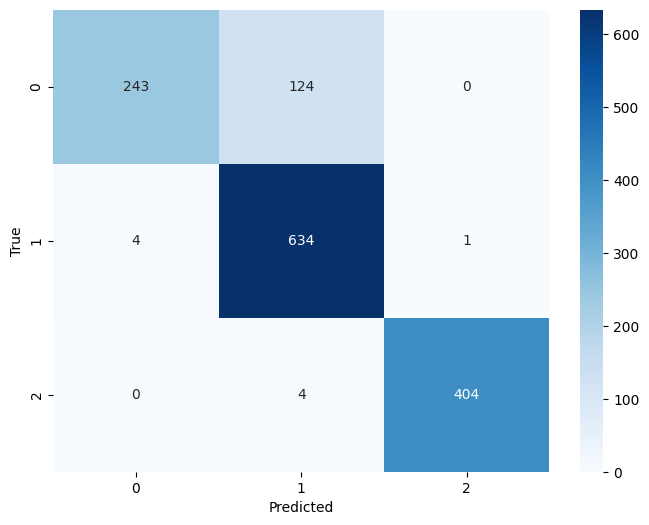

In [19]:
evaluate_model(model_mlp, X_test_mlp, y_test)

12. Evaluate LSTM

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
Accuracy: 0.8253182461103253
Macro F1: 0.7781155388813841
              precision    recall  f1-score   support

           0       1.00      0.33      0.50       367
           1       0.72      1.00      0.84       639
           2       1.00      1.00      1.00       408

    accuracy                           0.83      1414
   macro avg       0.91      0.78      0.78      1414
weighted avg       0.87      0.83      0.80      1414



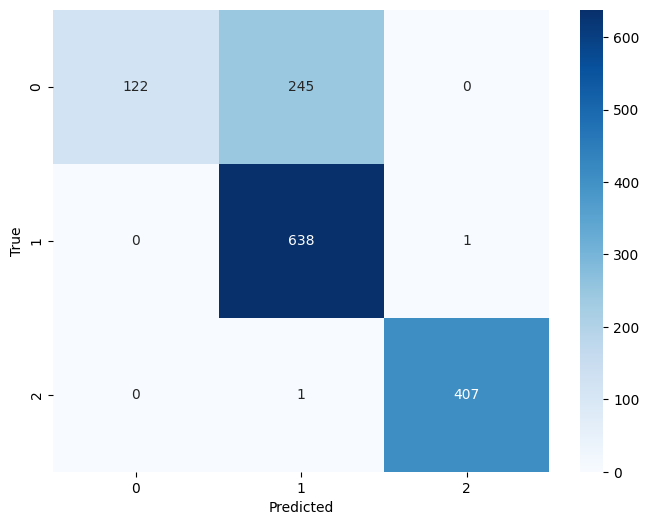

In [20]:
evaluate_model(model_lstm, X_test, y_test)

13. Compare Models

In [21]:
mlp_preds = np.argmax(model_mlp.predict(X_test_mlp), axis=1)
lstm_preds = np.argmax(model_lstm.predict(X_test), axis=1)

print("MLP Accuracy:", accuracy_score(y_test, mlp_preds))
print("LSTM Accuracy:", accuracy_score(y_test, lstm_preds))

print("MLP F1:", f1_score(y_test, mlp_preds, average='macro'))
print("LSTM F1:", f1_score(y_test, lstm_preds, average='macro'))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
MLP Accuracy: 0.905940594059406
LSTM Accuracy: 0.8253182461103253
MLP F1: 0.8968162306109525
LSTM F1: 0.7781155388813841


14. Plot Training Curves

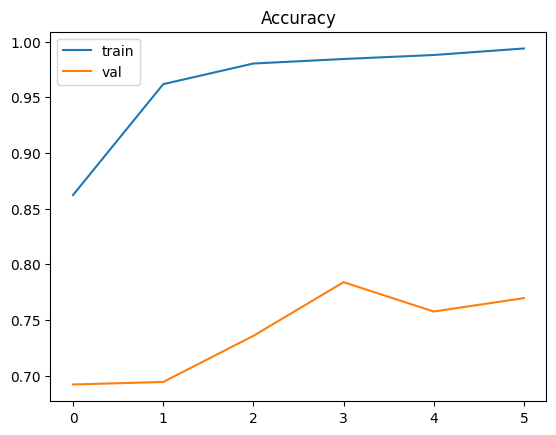

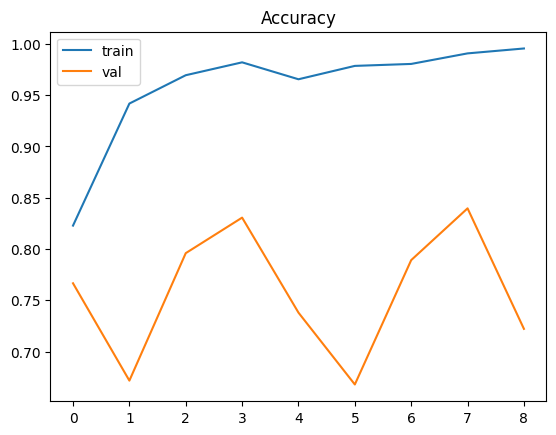

In [22]:
def plot_history(history):

    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.legend(['train','val'])
    plt.title("Accuracy")
    plt.show()

plot_history(history_mlp)
plot_history(history_lstm)